<a href="https://colab.research.google.com/github/JESUSJEREZ/Universidad_Javeriana/blob/main/Proyecto_Final_Peso_Bebes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **ENTENDIMIENTO DEL NEGOCIO ---- PESOS DE BEBES AL NACER**

Según estudios científicos1, el peso de los bebés al nacer está fuertemente
relacionado con riesgos de mortalidad durante los primeros meses, y problemas
durante la infancia y la adultez. Según la Organización Mundial de La Salud, entre el 15 y 20% de los nacimientos al año corresponden a bebés de bajo peso (inferior a 2500g o 5.5 Libras). Actualmente existen varias políticas públicas que buscan prevenir la mala salud de los bebés al nacer, mientras tanto, es tarea de las Entidades Prestadoras de Salud (EPS) prever la necesidad de cuidados adicionales para la madre y el neonato en caso de tener bajo peso.

En este Notebook se trabajarán los siguientes temas:

- Separación de Datos en Train/Val/Test
- Análisis de Correlaciones
- Ajuste del mejor SVM
- Métricas de Evaluación

* **Entendimiento del Negocio** - Planteamiento de Preguntas de Investigación.
* **Entendimiento de los Datos** - revisar la dispersión de los datos, la tendencia central, los sesgos en la distribución, las tablas de contingencia, las correlaciones,
* **Preparación de los Datos** - Scrubbing; Limpiar los datos garantizando que tengan un nivel de calidad adecuados para los análisis posteriores. Revisar problemas usuales como datos vacíos, inconsistentes, registros errados y actuar en concordancia con lo encontrado.
* **Explorar - Exploring**; Visualizar los datos para encontrar patrones y relaciones. *Muchas veces este paso es transversal, en especial con (S)*
* **Modelar - Modeling**; Modelar los datos para predecir o describir un comportamiento
* **Evaluar**; Interpretar los resultados de los modelos

![Metodologia CRISP-DM](https://www.researchgate.net/publication/381173766/figure/fig1/AS:11431281251253594@1718155200113/Figura-1-Metodologia-CRISP-DM.jpg)

# ENTENDIMIENTO DE LOS DATOS

## Cargar los datos

In [ ]:
# =======================
# 1. Importar librerías
# =======================
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb

In [ ]:
# Cargar la base de google drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# =======================
# 2. Cargar datos
# =======================
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Analitica II/peso_bebes.csv')

In [ ]:
df.shape

(4255156, 31)

In [ ]:
df.head()

,source_year,year,month,day,wday,state,is_male,child_race,weight_pounds,plurality,...,alcohol_use,drinks_per_week,weight_gain_pounds,born_alive_alive,born_alive_dead,born_dead,ever_born,father_race,father_age,record_weight
0,2022,2022,4,NaN,5,NaN,False,NaN,6.437498,1,...,NaN,NaN,30.0,NaN,NaN,NaN,8.0,NaN,49,1
1,2022,2022,3,NaN,5,NaN,False,NaN,7.262027,1,...,NaN,NaN,99.0,NaN,NaN,NaN,8.0,NaN,45,1
2,2022,2022,12,NaN,2,NaN,True,NaN,6.000983,1,...,NaN,NaN,54.0,NaN,NaN,NaN,8.0,NaN,38,1
3,2022,2022,10,NaN,4,NaN,True,NaN,8.126239,1,...,NaN,NaN,30.0,NaN,NaN,NaN,8.0,NaN,39,1
4,2022,2022,11,NaN,4,NaN,False,NaN,7.312733,1,...,NaN,NaN,10.0,NaN,NaN,NaN,8.0,NaN,40,1


## Analisis Exploratorio de los Datos

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4255156 entries, 0 to 4255155
Data columns (total 31 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   source_year             int64  
 1   year                    int64  
 2   month                   int64  
 3   day                     float64
 4   wday                    int64  
 5   state                   float64
 6   is_male                 bool   
 7   child_race              float64
 8   weight_pounds           float64
 9   plurality               int64  
 10  apgar_1min              float64
 11  apgar_5min              float64
 12  mother_residence_state  float64
 13  mother_race             float64
 14  mother_age              int64  
 15  gestation_weeks         float64
 16  lmp                     int64  
 17  mother_married          bool   
 18  mother_birth_state      float64
 19  cigarette_use           object 
 20  cigarettes_per_day      float64
 21  alcohol_use             object 

In [ ]:
df_summary = pd.DataFrame({
    "No_nulos": df.count(),
    "Nulos": df.isna().sum(),
    "%_completitud": round(df.count() / len(df) * 100, 2),
    "%_nulos": round(df.isna().sum() / len(df) * 100, 2)
})
print(df_summary)

                        No_nulos    Nulos  %_completitud  %_nulos
source_year              4255156        0         100.00     0.00
year                     4255156        0         100.00     0.00
month                    4255156        0         100.00     0.00
day                            0  4255156           0.00   100.00
wday                     4255156        0         100.00     0.00
state                          0  4255156           0.00   100.00
is_male                  4255156        0         100.00     0.00
child_race                     0  4255156           0.00   100.00
weight_pounds            4250791     4365          99.90     0.10
plurality                4255156        0         100.00     0.00
apgar_1min                     0  4255156           0.00   100.00
apgar_5min               4226384    28772          99.32     0.68
mother_residence_state         0  4255156           0.00   100.00
mother_race              1342509  2912647          31.55    68.45
mother_age

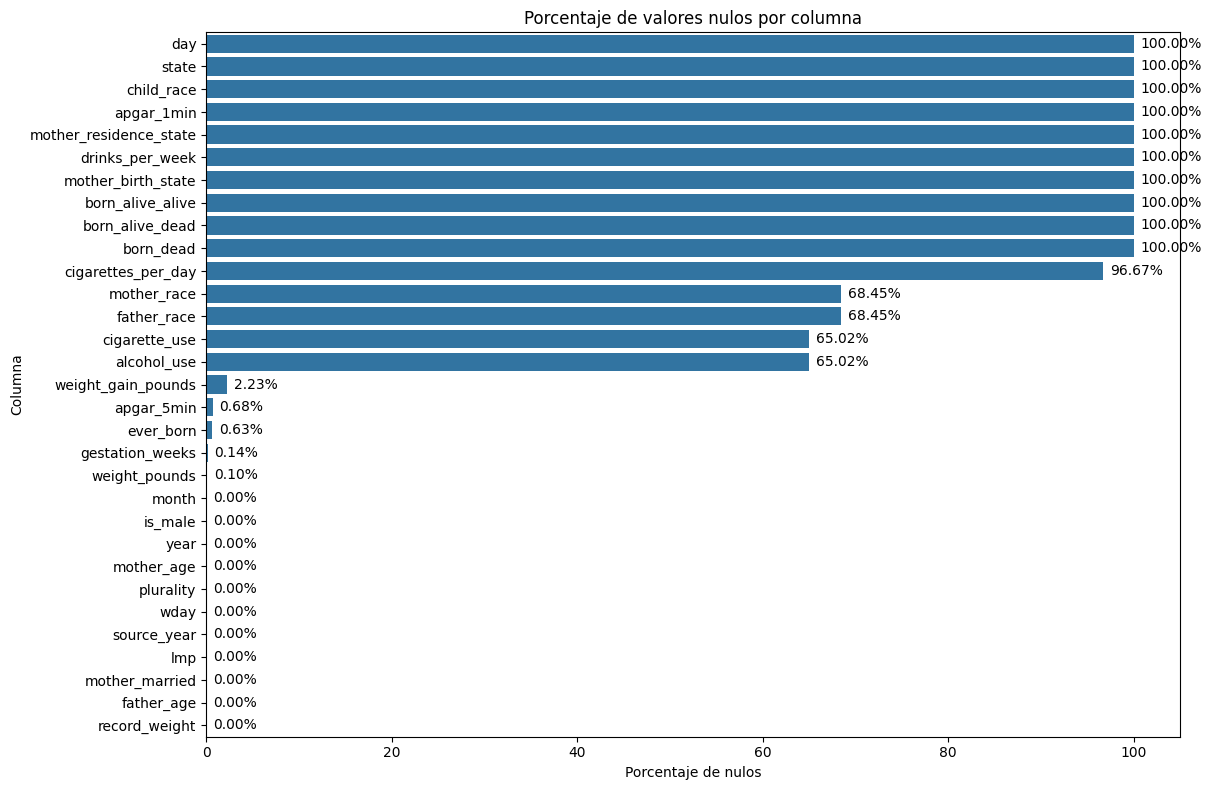

In [ ]:
plt.figure(figsize=(12, 8)) # Adjust figure size for better readability of horizontal bars
df_summary_sorted = df_summary.sort_values(by='%_nulos', ascending=False)
ax = sns.barplot(x='%_nulos', y=df_summary_sorted.index, data=df_summary_sorted)
plt.title("Porcentaje de valores nulos por columna")
plt.xlabel("Porcentaje de nulos")
plt.ylabel("Columna")
plt.tight_layout()

# Add percentage labels next to bars
for p in ax.patches:
    ax.annotate(f'{p.get_width():.2f}%', (p.get_width(), p.get_y() + p.get_height() / 2.),
                ha='left', va='center', xytext=(5, 0), textcoords='offset points')

plt.show()

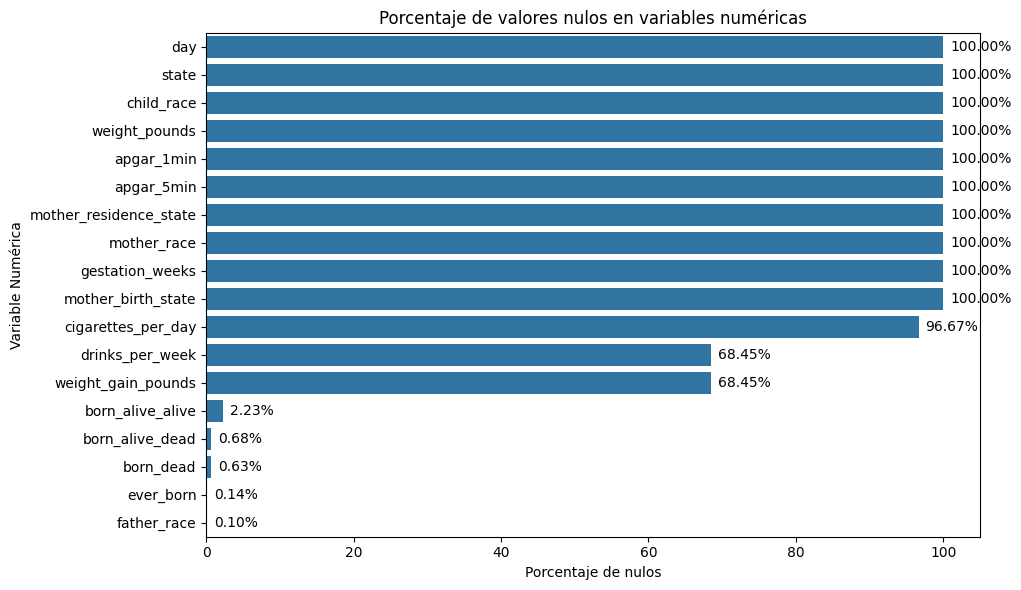

In [ ]:
# Identificar valores nulos de las variables numéricas
numerical_cols_with_nulls = df_summary[(df_summary['%_nulos'] > 0) & (df_summary.index.isin(df.select_dtypes(include=np.number).columns))].index

# Filter the summary dataframe for these columns
df_summary_numerical = df_summary.loc[numerical_cols_with_nulls]

plt.figure(figsize=(10, 6))
ax = sns.barplot(x='%_nulos', y=df_summary_numerical.index, data=df_summary_numerical.sort_values(by='%_nulos', ascending=False))
plt.title("Porcentaje de valores nulos en variables numéricas")
plt.xlabel("Porcentaje de nulos")
plt.ylabel("Variable Numérica")
plt.tight_layout()

# Add percentage labels next to bars
for p in ax.patches:
    ax.annotate(f'{p.get_width():.2f}%', (p.get_width(), p.get_y() + p.get_height() / 2.),
                ha='left', va='center', xytext=(5, 0), textcoords='offset points')

plt.show()

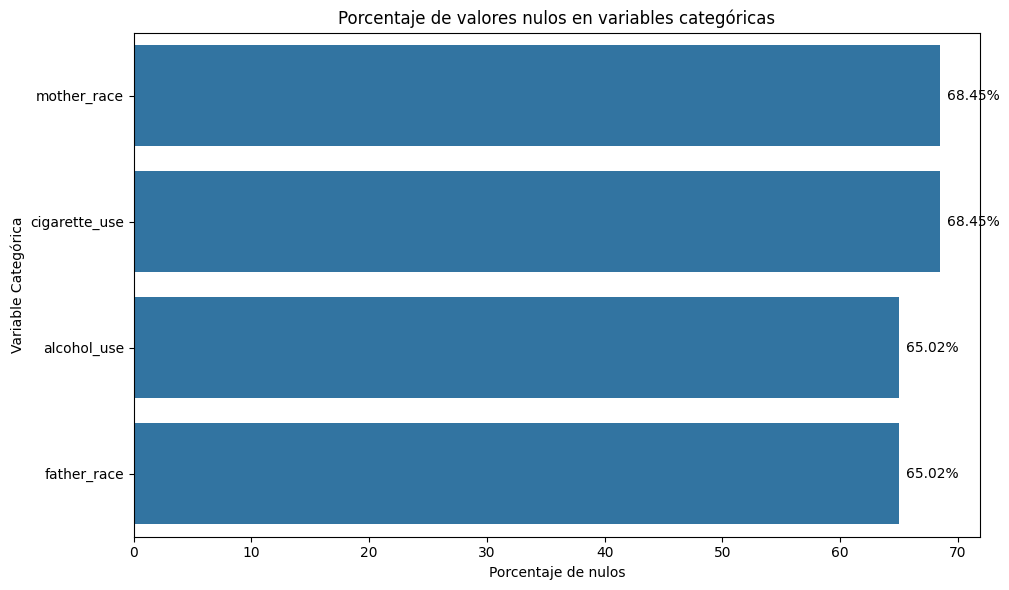

In [ ]:
# Identificar los valores nulos de las variables categoricas
categorical_cols_with_nulls = ['mother_race', 'cigarette_use', 'alcohol_use', 'father_race'] # Include father_race as it was filled with 99, originally had nulls

# Filter the summary dataframe for these columns
df_summary_categorical = df_summary.loc[categorical_cols_with_nulls]

plt.figure(figsize=(10, 6))
ax = sns.barplot(x='%_nulos', y=df_summary_categorical.index, data=df_summary_categorical.sort_values(by='%_nulos', ascending=False))
plt.title("Porcentaje de valores nulos en variables categóricas")
plt.xlabel("Porcentaje de nulos")
plt.ylabel("Variable Categórica")
plt.tight_layout()

# Add percentage labels next to bars
for p in ax.patches:
    ax.annotate(f'{p.get_width():.2f}%', (p.get_width(), p.get_y() + p.get_height() / 2.),
                ha='left', va='center', xytext=(5, 0), textcoords='offset points')

plt.show()

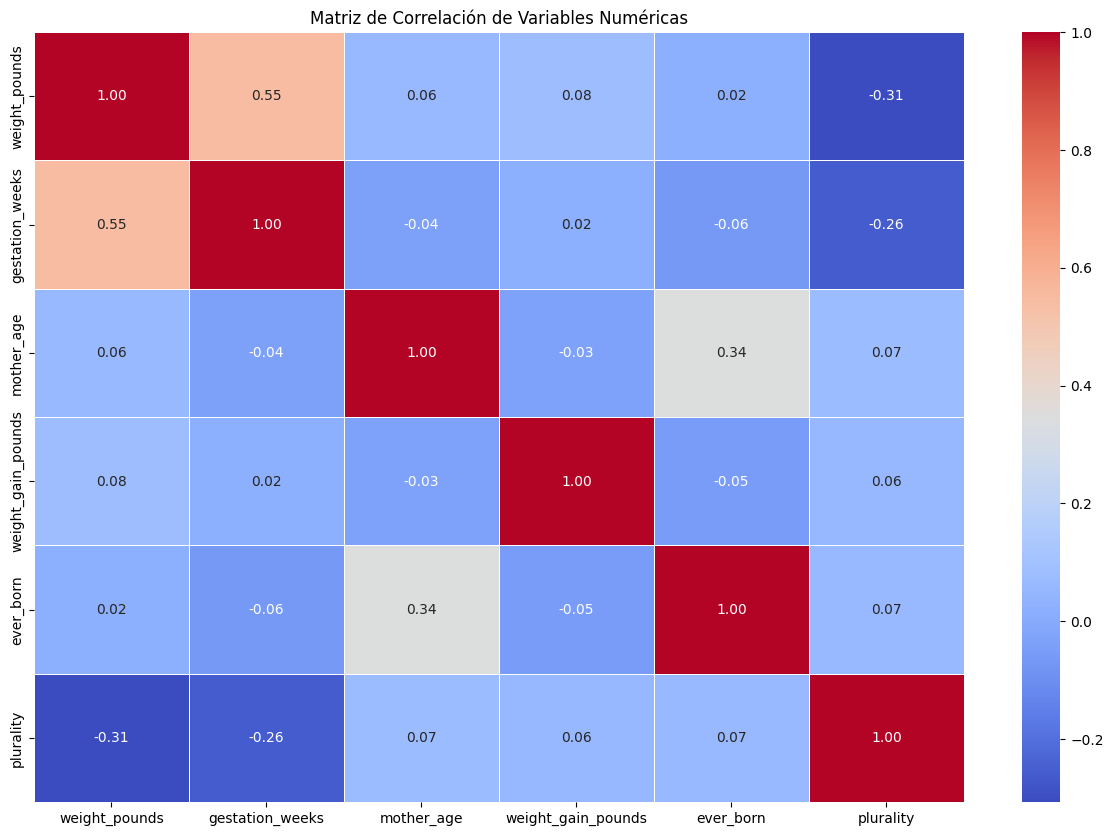

In [ ]:
# Calcular la matriz de correlación variables relevantes
# Seleccionar solo las columnas numéricas de las variables relevantes para la matriz de correlación
df_numeric = df[['weight_pounds','gestation_weeks','mother_age','weight_gain_pounds', 'ever_born','plurality']]

# Calcular la matriz de correlación
correlation_matrix = df_numeric.corr()

# Visualizar la matriz de correlación
plt.figure(figsize=(15, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title("Matriz de Correlación de Variables Numéricas")
plt.show()

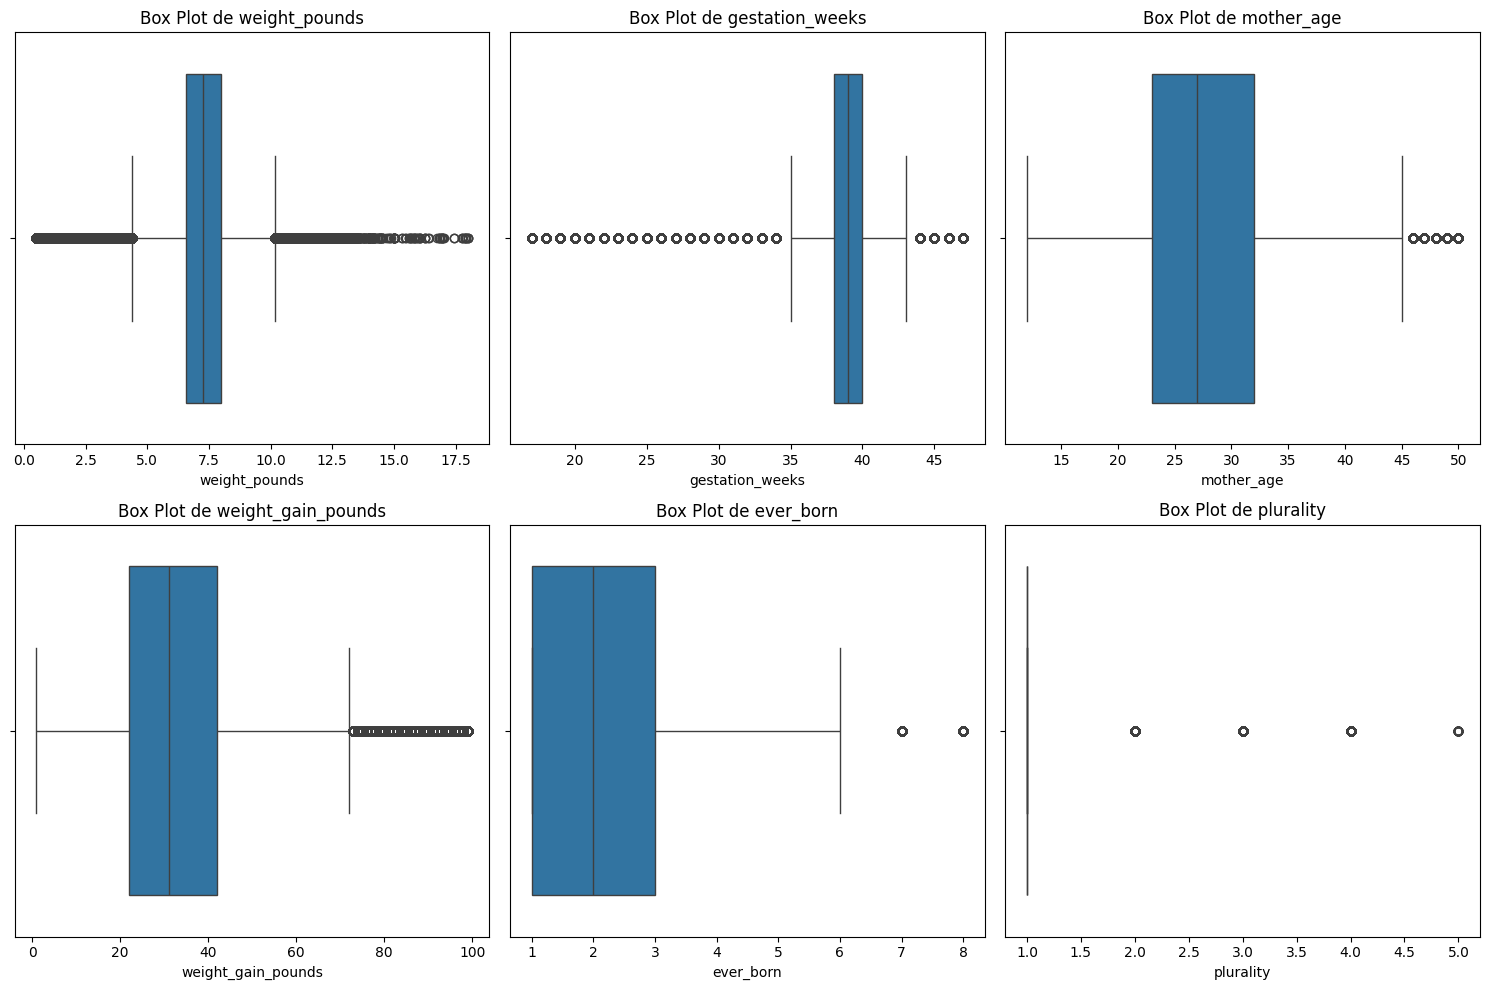

In [ ]:
# Variables para los box plots
variables_boxplot = ['weight_pounds','gestation_weeks','mother_age','weight_gain_pounds', 'ever_born','plurality']

# Crear box plots para cada variable
plt.figure(figsize=(15, 10))
for i, var in enumerate(variables_boxplot):
    plt.subplot(2, 3, i + 1) # Adjust subplot grid based on the number of variables
    sns.boxplot(x=df[var])
    plt.title(f'Box Plot de {var}')
    plt.xlabel(var)
plt.tight_layout()
plt.show()

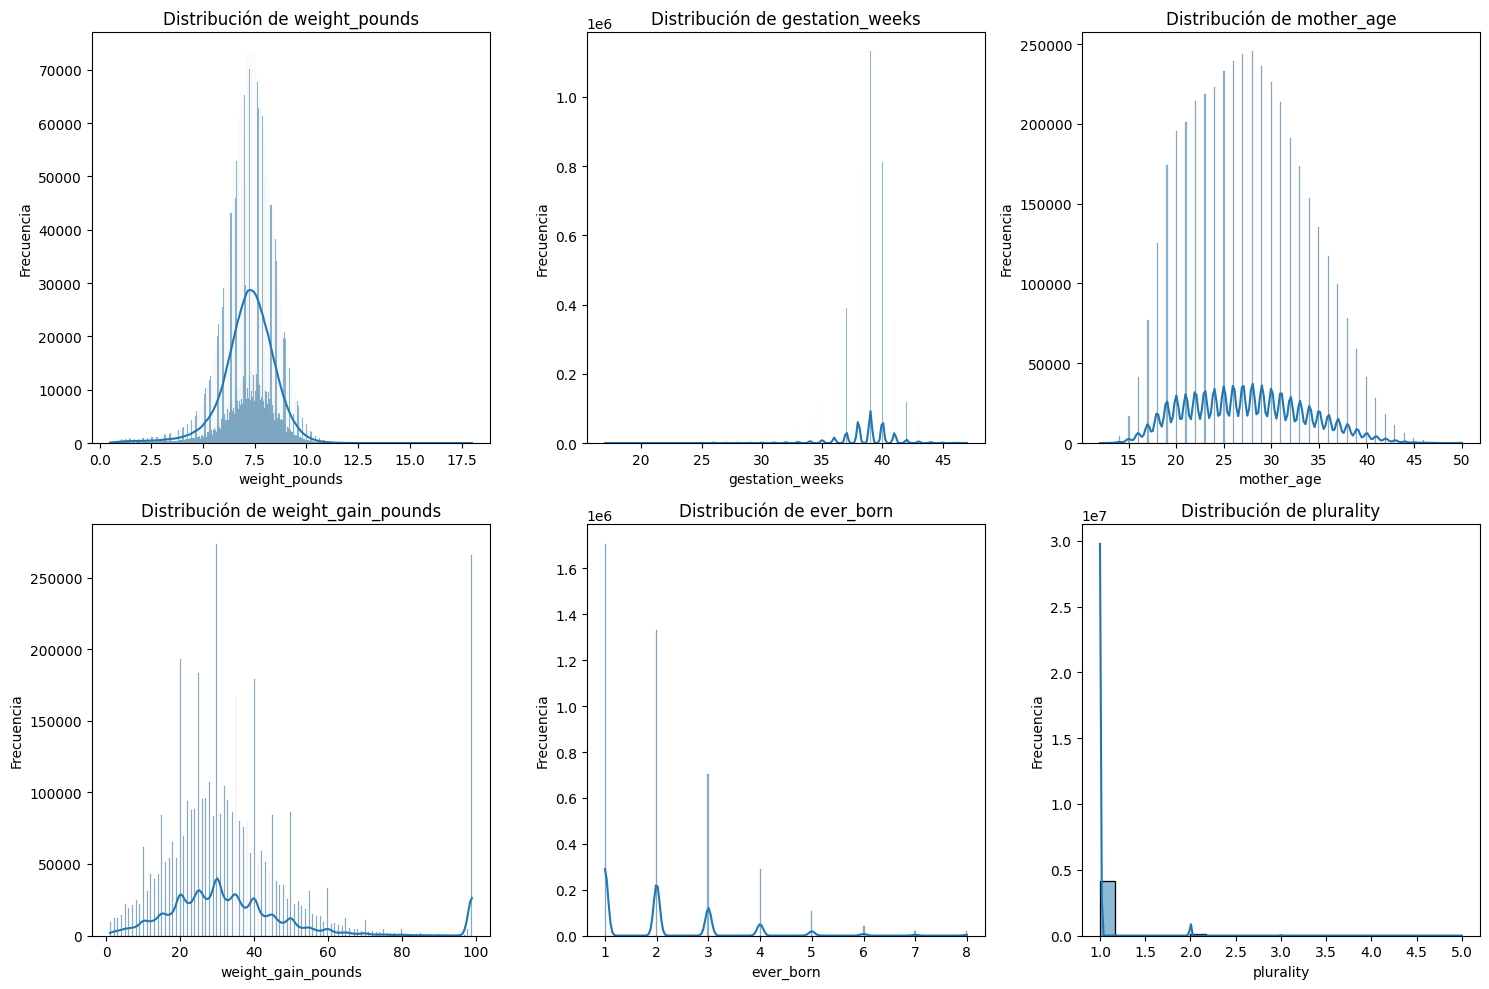

In [ ]:
# Variables para los histogramas
variables_histograma = ['weight_pounds','gestation_weeks','mother_age','weight_gain_pounds', 'ever_born','plurality']

# Crear histogramas para cada variable
plt.figure(figsize=(15, 10))
for i, var in enumerate(variables_histograma):
    plt.subplot(2, 3, i + 1) # Ajusta la cuadrícula según el número de variables
    sns.histplot(data=df, x=var, kde=True) # Añade kde=True para ver la densidad estimada
    plt.title(f'Distribución de {var}')
    plt.xlabel(var)
    plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

In [ ]:
# Identificar las variables categóricas
categorical_cols = ['mother_race', 'cigarette_use', 'alcohol_use', 'father_race']

print("Análisis de Frecuencias de Variables Categóricas:")

for col in categorical_cols:
    if col in df.columns:
        print(f"\n--- Frecuencia de '{col}' ---")
        # Use value_counts with dropna=False to include NaN counts if they still exist
        display(df[col].value_counts(dropna=False))
    else:
        print(f"\n⚠️ La columna '{col}' no existe en el DataFrame.")

Análisis de Frecuencias de Variables Categóricas:

--- Frecuencia de 'mother_race' ---


,count
mother_race,
NaN,2912647
1.0,993066
2.0,262136
78.0,23968
3.0,22546
18.0,12847
7.0,8064
4.0,7279
68.0,5605



--- Frecuencia de 'cigarette_use' ---


,count
cigarette_use,
NaN,2766677
False,1346716
True,141763



--- Frecuencia de 'alcohol_use' ---


,count
alcohol_use,
NaN,2766677
False,1346716
True,141763



--- Frecuencia de 'father_race' ---


,count
father_race,
NaN,2912647
1.0,844036
99.0,243138
2.0,184801
78.0,20466
3.0,15441
18.0,12785
4.0,6266
7.0,5475


Análisis Gráfico de Frecuencias de Variables Categóricas:


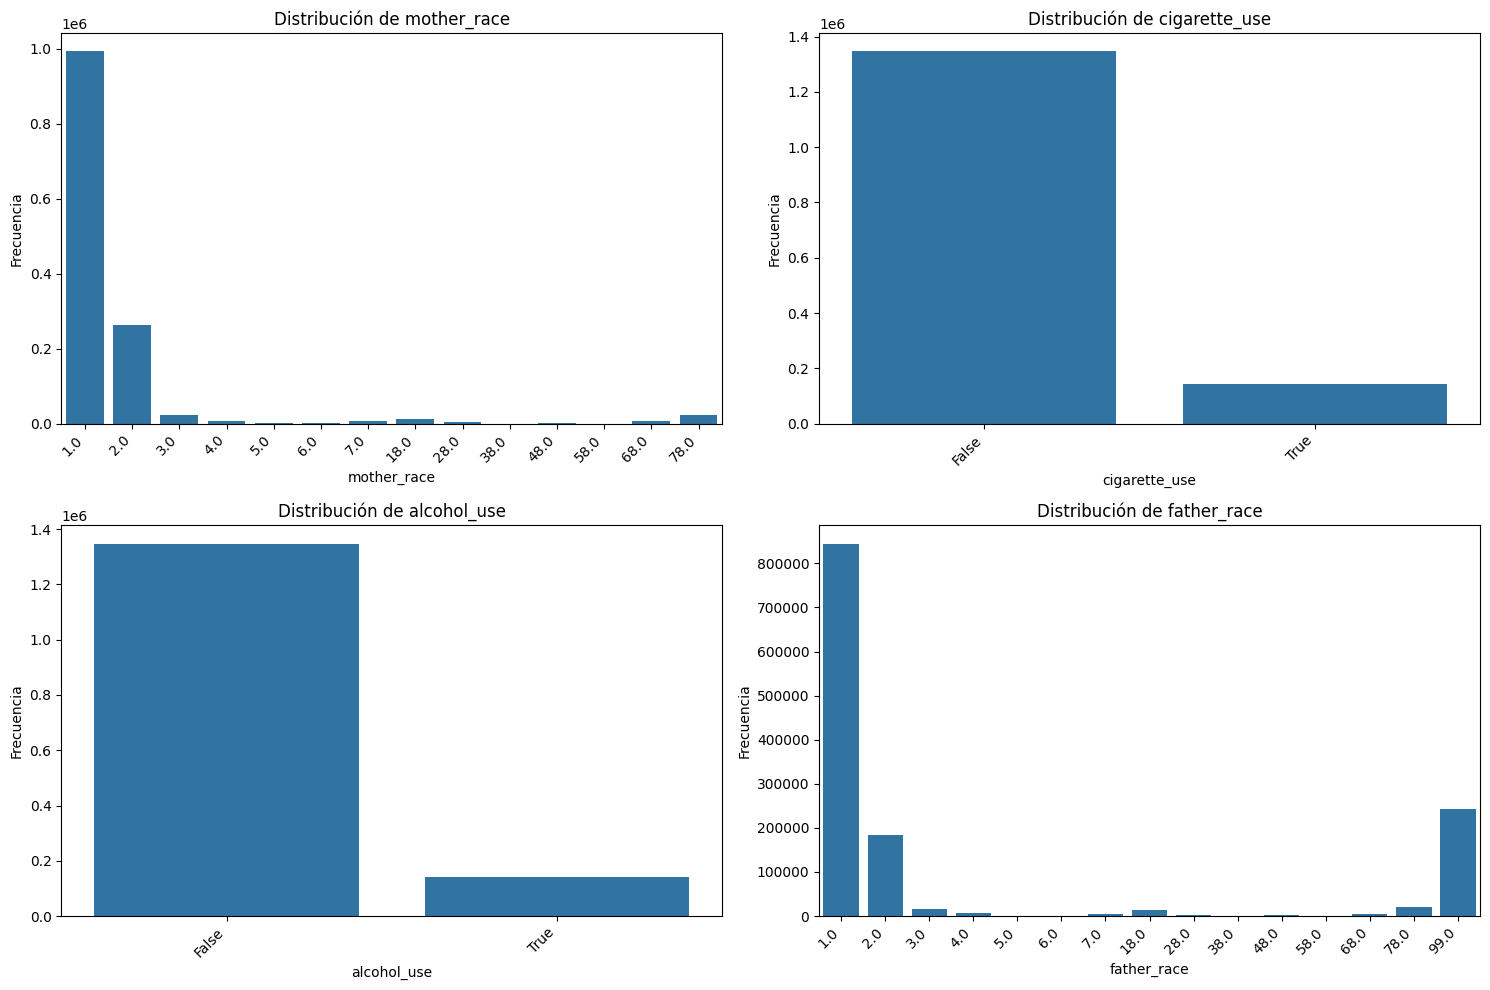

In [ ]:
# Variables categóricas para análisis gráfico
categorical_cols_for_plot = ['mother_race', 'cigarette_use', 'alcohol_use', 'father_race']

print("Análisis Gráfico de Frecuencias de Variables Categóricas:")

# Create bar plots for each categorical variable
plt.figure(figsize=(15, 10))
for i, col in enumerate(categorical_cols_for_plot):
    if col in df.columns:
        plt.subplot(2, 2, i + 1)  # Adjust subplot grid
        # Calculate value counts and plot
        sns.countplot(data=df, x=col)
        plt.title(f'Distribución de {col}')
        plt.xlabel(col)
        plt.ylabel("Frecuencia")
        plt.xticks(rotation=45, ha='right') # Rotate labels for better readability
    else:
        print(f"\n⚠️ La columna '{col}' no existe en el DataFrame.")

plt.tight_layout()
plt.show()

### Reporte de Análisis Exploratorio - EDA

In [ ]:
%pip install ydata-profiling

In [ ]:
from ydata_profiling import ProfileReport
from datetime import datetime, timedelta

In [ ]:
profile = ProfileReport(df, title='Reporte Eda Bebes al Nacer')
profile.to_notebook_iframe()
profile.to_file("reporte_eda.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 31/31 [01:15<00:00,  2.44s/it]


# PREPARACIÒN DE LOS DATOS

In [ ]:
# =======================
# 3. Limpiar datos
# =======================

# 3.1 — Eliminar variables que no tienen datos

df = df.drop(columns=["source_year","year","day","state","child_race","apgar_1min","mother_residence_state","mother_birth_state","drinks_per_week","born_alive_alive","born_alive_dead","born_dead"])

In [ ]:
df.head()

In [ ]:
df.info()

In [ ]:
df.describe()

In [ ]:
df_summary = pd.DataFrame({
    "No_nulos": df.count(),
    "Nulos": df.isna().sum(),
    "%_completitud": round(df.count() / len(df) * 100, 2)
})
print(df_summary)

In [ ]:
# 3.2 — Los valores nulos de la variable weight_pounds se eliminan dado que es la variable que queremos predecir

if "weight_pounds" in df.columns:
    before = len(df)
    df = df.dropna(subset=["weight_pounds"]).reset_index(drop=True)
    after = len(df)
    print(f"Se eliminaron {before - after} registros con 'weight_pounds' nulo. Total final: {after}")
else:
    print("La columna 'weight_pounds' no existe en el DataFrame.")

In [ ]:
# 3.3 — Crea variable peso_bebe en gramos

if "weight_pounds" in df.columns:
    df["peso_bebe"] = df["weight_pounds"] * 453.59237
    print("✅ Nueva columna 'peso_bebe' creada (en gramos). Ejemplo:")
    print(df[["weight_pounds", "peso_bebe"]].head())
else:
    print("⚠️ La columna 'weight_pounds' no existe en el DataFrame.")

In [ ]:
df = df.drop(columns=["weight_pounds"])

In [ ]:
# 3.4 — Asigna codigo 99 a nulos en mother_race

if "mother_race" in df.columns:
    before = df["mother_race"].isna().sum()
    df["mother_race"] = df["mother_race"].fillna(99).astype(int)
    after = df["mother_race"].isna().sum()
    print(f"Se reemplazaron {before - after} valores nulos por 99 en 'mother_race'. Total actual de registros: {len(df)}")
else:
    print("La columna 'mother_race' no existe en el DataFrame.")

In [ ]:
# 3.5 — Asigna codigo 99 a nulos en father_race

if "father_race" in df.columns:
    before = df["father_race"].isna().sum()
    df["father_race"] = df["father_race"].fillna(99).astype(int)
    after = df["father_race"].isna().sum()
    print(f"Se reemplazaron {before - after} valores nulos por 99 en 'father_race'. Total actual de registros: {len(df)}")
else:
    print("La columna 'father_race' no existe en el DataFrame.")

In [ ]:
# 3.6 Conversión de variables booleanas

# Verificar si las columnas existen antes de convertirlas
for col in ["is_male", "mother_married"]:
    if col in df.columns:
        # Mostrar valores únicos antes de la conversión
        print(f"\nAntes de la conversión — {col}:")
        print(df[col].value_counts(dropna=False))

        # Convertir True/False a 1/0
        df[col] = df[col].map({True: 1, False: 0})

        # Mostrar valores después de la conversión
        print(f"\nDespués de la conversión — {col}:")
        print(df[col].value_counts(dropna=False))
    else:
        print(f"⚠️ La columna '{col}' no existe en el DataFrame.")

# Confirmar los tipos de datos finales
print("\n✅ Tipos de datos después de la conversión:")
print(df[["is_male", "mother_married"]].dtypes)

In [ ]:
# 3.7 Conversión de variables booleanas

if "cigarette_use" in df.columns:
    print("Antes de la conversión:")
    print(df["cigarette_use"].value_counts(dropna=False))

    # Convertir True → 1, False → 0, mantener NaN igual
    df["cigarette_use"] = df["cigarette_use"].map({True: 1, False: 0})

    print("\nDespués de la conversión:")
    print(df["cigarette_use"].value_counts(dropna=False))
    print(f"\nTipo de dato: {df['cigarette_use'].dtype}")
else:
    print("⚠️ La columna 'cigarette_use' no existe en el DataFrame.")

In [ ]:
# 3.7 Conversión de variables booleanas

if "alcohol_use" in df.columns:
    print("Antes de la conversión:")
    print(df["alcohol_use"].value_counts(dropna=False))

    # Convertir True → 1, False → 0, mantener NaN
    df["alcohol_use"] = df["alcohol_use"].map({True: 1, False: 0})

    print("\nDespués de la conversión:")
    print(df["alcohol_use"].value_counts(dropna=False))
    print(f"\nTipo de dato: {df['alcohol_use'].dtype}")
else:
    print("⚠️ La columna 'alcohol_use' no existe en el DataFrame.")

In [ ]:
df_summary = pd.DataFrame({
    "No_nulos": df.count(),
    "Nulos": df.isna().sum(),
    "%_completitud": round(df.count() / len(df) * 100, 2)
})
print(df_summary)

In [ ]:
df.describe()

In [ ]:
df.head()

In [ ]:
df.info()

## Definir variable objetivo y división en train y test

1.   List item
2.   List item



In [ ]:
# =======================================
# 4. Definir variables predictoras y objetivo
# =======================================

X = df.drop(columns=["peso_bebe"])
y = df["peso_bebe"]

In [ ]:
# =======================================
# 5. Dividir en entrenamiento y prueba
# =======================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Datos de entrenamiento: {X_train.shape[0]} filas")
print(f"Datos de prueba: {X_test.shape[0]} filas")

## Ingenuo

In [ ]:
from sklearn.linear_model import LinearRegression

# Filtrar datos sin nulos
mask = X_train["gestation_weeks"].notna() & y_train.notna()
lin_model = LinearRegression()
lin_model.fit(X_train.loc[mask, ["gestation_weeks"]], y_train[mask])

# Predicción
y_pred_lin = lin_model.predict(X_test[["gestation_weeks"]].fillna(X_train["gestation_weeks"].median()))

mae = mean_absolute_error(y_test, y_pred_lin)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_lin))
r2 = r2_score(y_test, y_pred_lin)

print("📊 Modelo ingenuo (Regresión simple con 'gestation_weeks')")
print(f"MAE: {mae:,.2f}")
print(f"RMSE: {rmse:,.2f}")
print(f"R²: {r2:.3f}")

# MODELAMIENTO

## Modelo Nº 1: CatBoost

In [ ]:
%pip install catboost

In [ ]:
# 1. Install CatBoost (if not already installed)
# %pip install catboost # Assuming this was run earlier or will be run

# 2. Import necessary libraries
from catboost import CatBoostRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
# 3. Handle missing values (using imputation based on EDA)
# Identify numerical columns with null values after initial cleaning
numerical_cols_with_nulls_after_clean = ['apgar_5min', 'gestation_weeks', 'cigarettes_per_day', 'weight_gain_pounds', 'ever_born']

In [ ]:
# Identify categorical columns with null values after initial cleaning (converted to float)
categorical_cols_with_nulls_after_clean = ['cigarette_use', 'alcohol_use']

In [ ]:
# Impute numerical columns with the median
# Use X_train to fit the imputer to avoid data leakage from the test set
from sklearn.impute import SimpleImputer
imputer_numerical = SimpleImputer(strategy='median')
X_train_imputed_numerical = imputer_numerical.fit_transform(X_train[numerical_cols_with_nulls_after_clean])
X_test_imputed_numerical = imputer_numerical.transform(X_test[numerical_cols_with_nulls_after_clean])

In [ ]:
# Impute categorical columns with a constant value (e.g., -1)
imputer_categorical = SimpleImputer(strategy='constant', fill_value=-1)
X_train_imputed_categorical = imputer_categorical.fit_transform(X_train[categorical_cols_with_nulls_after_clean])
X_test_imputed_categorical = imputer_categorical.transform(X_test[categorical_cols_with_nulls_after_clean])

In [ ]:
# Create new dataframes with imputed columns, preserving original column names
X_train_imputed_numerical_df = pd.DataFrame(X_train_imputed_numerical, columns=numerical_cols_with_nulls_after_clean, index=X_train.index)
X_test_imputed_numerical_df = pd.DataFrame(X_test_imputed_numerical, columns=numerical_cols_with_nulls_after_clean, index=X_test.index)

X_train_imputed_categorical_df = pd.DataFrame(X_train_imputed_categorical, columns=categorical_cols_with_nulls_after_clean, index=X_train.index)
X_test_imputed_categorical_df = pd.DataFrame(X_test_imputed_categorical, columns=categorical_cols_with_nulls_after_clean, index=X_test.index)

In [ ]:
# Drop original columns with nulls and concatenate with imputed columns
X_train_imputed = X_train.drop(columns=numerical_cols_with_nulls_after_clean + categorical_cols_with_nulls_after_clean).copy()
X_train_imputed = pd.concat([X_train_imputed, X_train_imputed_numerical_df, X_train_imputed_categorical_df], axis=1)

X_test_imputed = X_test.drop(columns=numerical_cols_with_nulls_after_clean + categorical_cols_with_nulls_after_clean).copy()
X_test_imputed = pd.concat([X_test_imputed, X_test_imputed_numerical_df, X_test_imputed_categorical_df], axis=1)

# Verify that there are no more null values in the imputed dataframes
print("Missing values in X_train_imputed after imputation:")
print(X_train_imputed.isnull().sum().sum())
print("Missing values in X_test_imputed after imputation:")
print(X_test_imputed.isnull().sum().sum())

Missing values in X_train_imputed after imputation:
0
Missing values in X_test_imputed after imputation:
0


In [ ]:
# 4. Define and train the CatBoost model
from catboost import CatBoostRegressor

catboost_model = CatBoostRegressor(
    random_state=42,
    verbose=200  # Show training progress every 200 boosting rounds
)

print("🚀 Iniciando entrenamiento del modelo CatBoost...")
catboost_model.fit(X_train_imputed, y_train)
print("✅ Entrenamiento del modelo CatBoost completado.")

🚀 Iniciando entrenamiento del modelo CatBoost...
Learning rate set to 0.147967
0:	learn: 561.5429046	total: 626ms	remaining: 10m 25s
200:	learn: 442.5440594	total: 1m 55s	remaining: 7m 38s
400:	learn: 441.8594788	total: 3m 52s	remaining: 5m 47s
600:	learn: 441.4580247	total: 5m 48s	remaining: 3m 51s
800:	learn: 441.1212652	total: 7m 42s	remaining: 1m 54s
999:	learn: 440.8415789	total: 9m 36s	remaining: 0us
✅ Entrenamiento del modelo CatBoost completado.


In [ ]:
# 5. Evaluate the model
y_pred_catboost = catboost_model.predict(X_test_imputed)

mae = mean_absolute_error(y_test, y_pred_catboost)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_catboost))
r2 = r2_score(y_test, y_pred_catboost)

print("\n📊 Desempeño del modelo CatBoost:")
print(f"MAE  (Error absoluto medio): {mae:,.2f}")
print(f"RMSE (Raíz del error cuadrático medio): {rmse:,.2f}")
print(f"R²   (Coeficiente de determinación): {r2:.3f}")

# 6. Feature Importance (Optional)
import matplotlib.pyplot as plt
import seaborn as sns


📊 Desempeño del modelo CatBoost:
MAE  (Error absoluto medio): 341.94
RMSE (Raíz del error cuadrático medio): 441.59
R²   (Coeficiente de determinación): 0.443


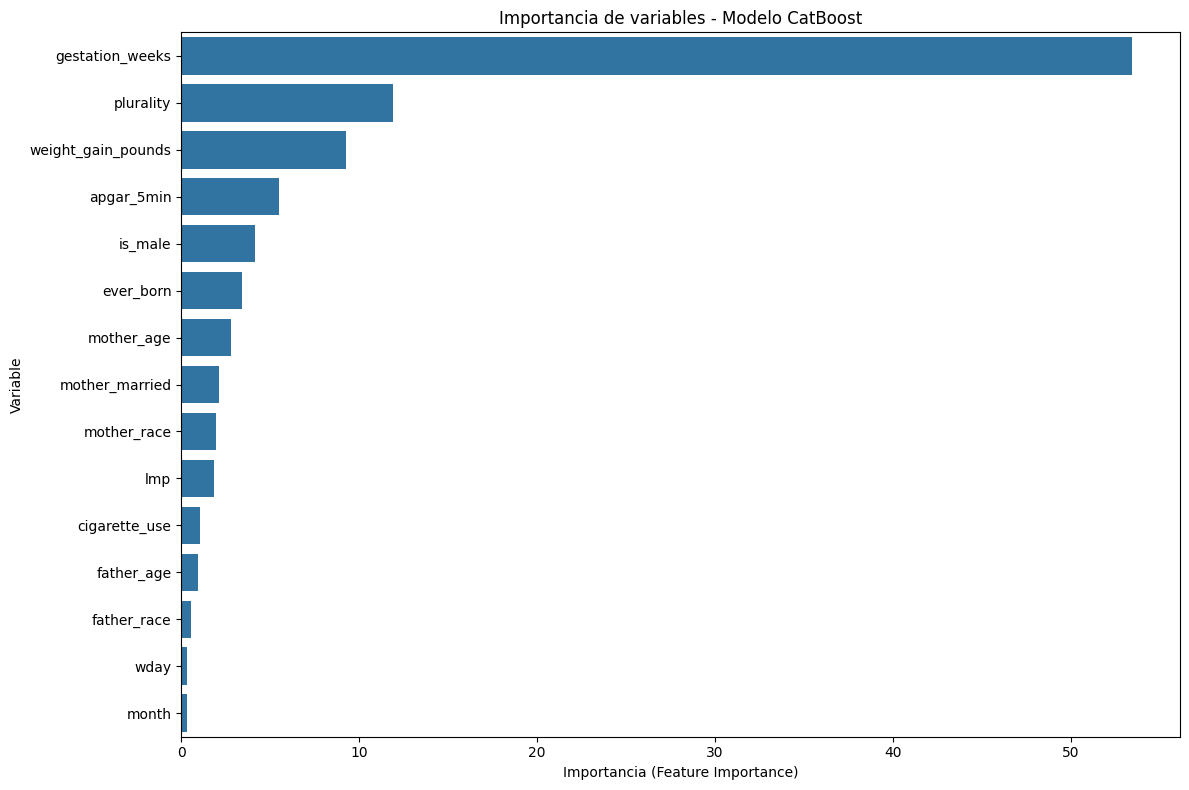

In [ ]:
# Get feature importances
feature_importances = catboost_model.get_feature_importance()

# Get feature names
feature_names = X_train_imputed.columns

# Create a DataFrame for importance and names
importance_df = pd.DataFrame({'feature': feature_names, 'importance': feature_importances})

# Sort by importance in descending order
importance_df = importance_df.sort_values(by='importance', ascending=False)

# Plot the top 15 features
plt.figure(figsize=(12, 8))
sns.barplot(x='importance', y='feature', data=importance_df.head(15))
plt.title("Importancia de variables - Modelo CatBoost")
plt.xlabel("Importancia (Feature Importance)")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()

## Modelo Nº 2: XGBoost

In [ ]:
# =======================================
# 6. Definir modelo base
# =======================================
xgb = XGBRegressor(
    objective='reg:squarederror',
    random_state=42,
    tree_method='hist',     # más eficiente para grandes volúmenes de datos
    eval_metric='rmse'      # métrica de evaluación interna
)

In [ ]:
# =======================================
# 7. Definir el espacio de búsqueda de hiperparámetros
# =======================================
param_dist = {
    'n_estimators': [200, 300, 400, 500],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'max_depth': [3, 4, 5, 6],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'gamma': [0, 0.1, 0.2, 0.3],
    'min_child_weight': [1, 3, 5]
}

In [ ]:
# =======================================
# 8. Configurar la búsqueda aleatoria
# =======================================
random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=30,                          # número de combinaciones aleatorias a probar
    scoring='neg_mean_absolute_error',  # métrica de selección (MAE)
    cv=3,                               # validación cruzada
    n_jobs=-1,                          # usar todos los núcleos disponibles
    random_state=42,
    verbose=2
)

print("🎲 Iniciando búsqueda aleatoria de hiperparámetros...")
random_search.fit(X_train, y_train)
print("\n📊 Desempeño del modelo XGBoost:")
print(f"MAE  (Error absoluto medio): {mae:,.2f}")
print(f"RMSE (Raíz del error cuadrático medio): {rmse:,.2f}")
print(f"R²   (Coeficiente de determinación): {r2:.3f}")

In [ ]:
# =======================================
# 9. Mostrar los mejores hiperparámetros
# =======================================
print("\n✅ Mejores hiperparámetros encontrados:")
print(random_search.best_params_)

# Extraer el mejor modelo
best_xgb = random_search.best_estimator_

In [ ]:
# =======================================
# 10. Evaluación del modelo en el set de prueba
# =======================================
y_pred = best_xgb.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\n📊 Desempeño del mejor modelo:")
print(f"MAE  (Error absoluto medio): {mae:,.2f}")
print(f"RMSE (Raíz del error cuadrático medio): {rmse:,.2f}")
print(f"R²   (Coeficiente de determinación): {r2:.3f}")

In [ ]:
# =======================================
# 11. Importancia de variables
# =======================================
import xgboost as xgb
import matplotlib.pyplot as plt

# Gráfico de importancia de variables
plt.figure(figsize=(10,6))
xgb.plot_importance(best_xgb, max_num_features=15)
plt.title("Importancia de variables - Mejor modelo XGBoost (RandomizedSearchCV)")
plt.show()

## Modelo Nº 3: Johan Higuera

## Modelo Nº 4: Daniel Conde

## Modelo Nº 5: Maria Angelica

## Modelo Nº 6: Nelson Rivera

# Interpretación de Resultados

¿Qué puede decir respecto a los resultados obtenidos de la línea base y los modelos? ¿Cómo impactan sus resultados?